<a href="https://colab.research.google.com/github/umiSirya/KRA_revenue_optimization/blob/main/KRA_revenue_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Importing important libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
drivers = pd.read_csv('/content/key-revenue-drivers-for-kenya.csv')
taxheads = pd.read_csv('/content/performance-of-key-tax-heads.csv')

# **EDA**

In [3]:
drivers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Revenue Drivers              6 non-null      object 
 1   Revenue Collection (Bn Shs)  6 non-null      float64
dtypes: float64(1), object(1)
memory usage: 228.0+ bytes


In [4]:
drivers

,Revenue Drivers,Revenue Collection (Bn Shs)
0,Tax Amnesty,43.900
1,Debt collection initiatives,103.390
2,Betting and Gaming Tax,24.269
3,Tax Base Expansion,24.620
4,Dispute resolution framework,60.469
5,Anti-Corruption Measures,4.220


In [5]:
taxheads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Tax Head               6 non-null      object 
 1   Revenue Growth (%)     6 non-null      float64
 2   Tax Revenue (Bn Shs.)  6 non-null      float64
dtypes: float64(2), object(1)
memory usage: 276.0+ bytes


In [6]:
taxheads

,Tax Head,Revenue Growth (%),Tax Revenue (Bn Shs.)
0,Capital Gains Tax,49.5,8.381
1,Excise on betting,26.2,24.269
2,Domestic Excise,8.1,73.624
3,Corporation Tax,4.9,278.156
4,Domestic VAT,15.3,314.157
5,PAYE,9.7,543.186


In [11]:
# sorting the revenue drivers
drivers_sorted = drivers.sort_values('Revenue Collection (Bn Shs)')

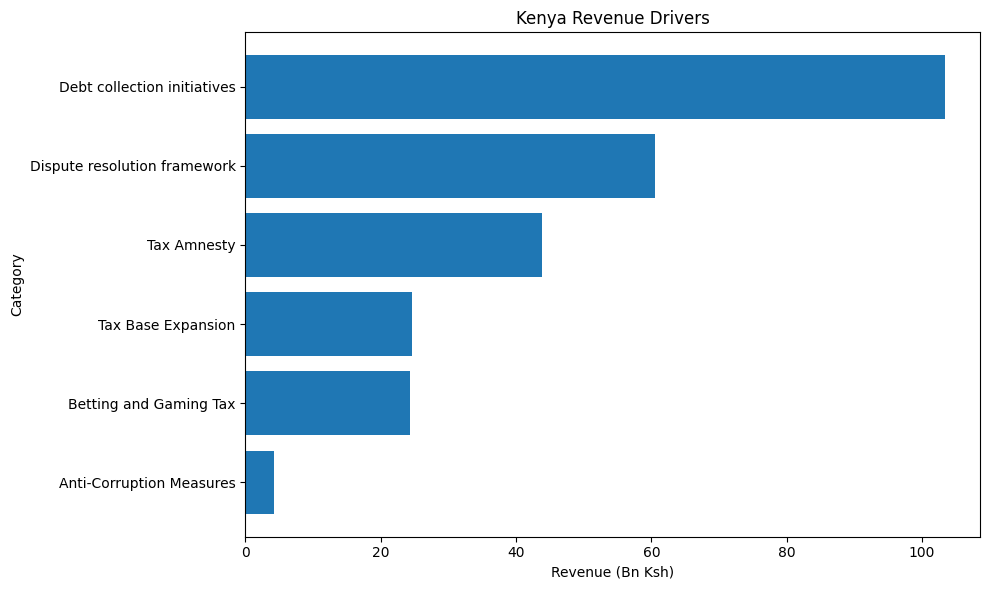

In [12]:
# Which revenue driver brings in the most money?

plt.figure(figsize=(10, 6))
plt.barh(drivers_sorted['Revenue Drivers'], drivers_sorted['Revenue Collection (Bn Shs)'])
plt.title('Kenya Revenue Drivers')
plt.xlabel('Revenue (Bn Ksh)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [17]:
# sorting the tax heads
taxheads_sorted = taxheads.sort_values('Revenue Growth (%)')

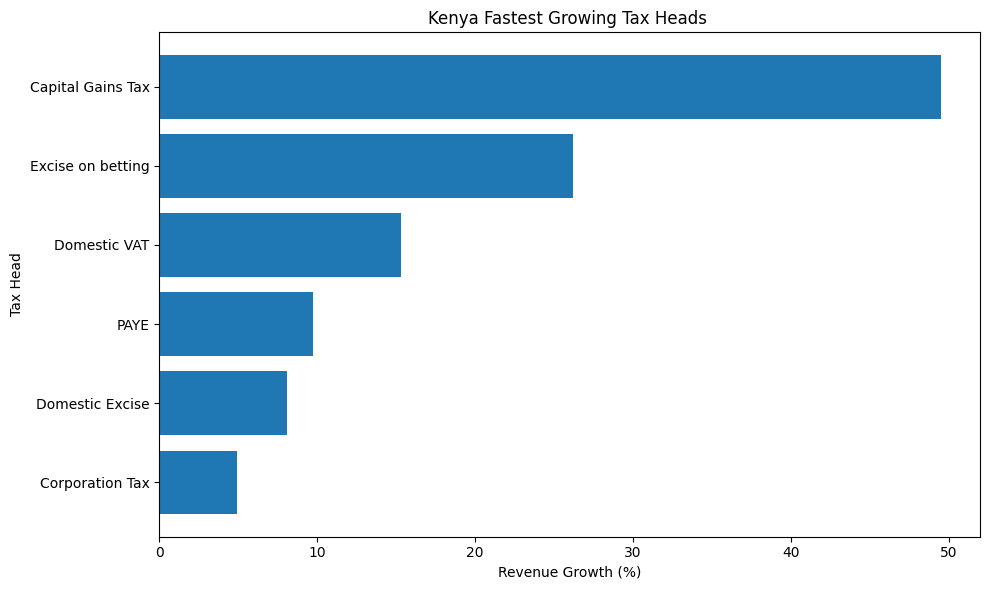

In [19]:
# Which tax head is the fastest growing?

plt.figure(figsize=(10, 6))
plt.barh(taxheads_sorted['Tax Head'], taxheads_sorted['Revenue Growth (%)'])
plt.title('Kenya Fastest Growing Tax Heads ')
plt.xlabel('Revenue Growth (%)')
plt.ylabel('Tax Head')
plt.tight_layout()
plt.show()

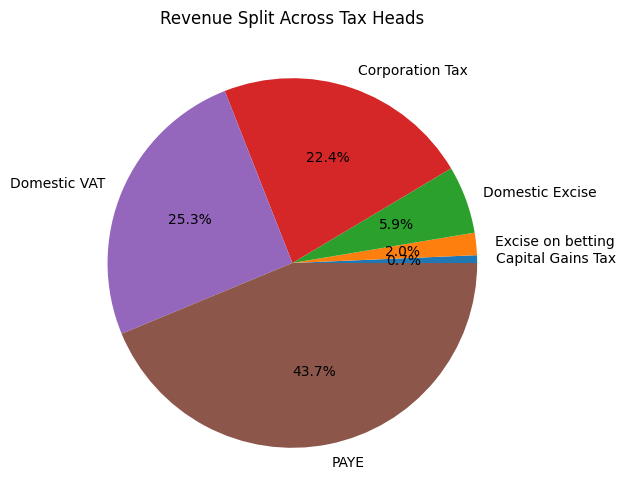

In [26]:
# How is total revenue split across tax heads?

plt.figure(figsize=(10, 6))
plt.pie(taxheads['Tax Revenue (Bn Shs.)'], labels=taxheads['Tax Head'], autopct='%1.1f%%')
plt.title('Revenue Split Across Tax Heads')
plt.show()


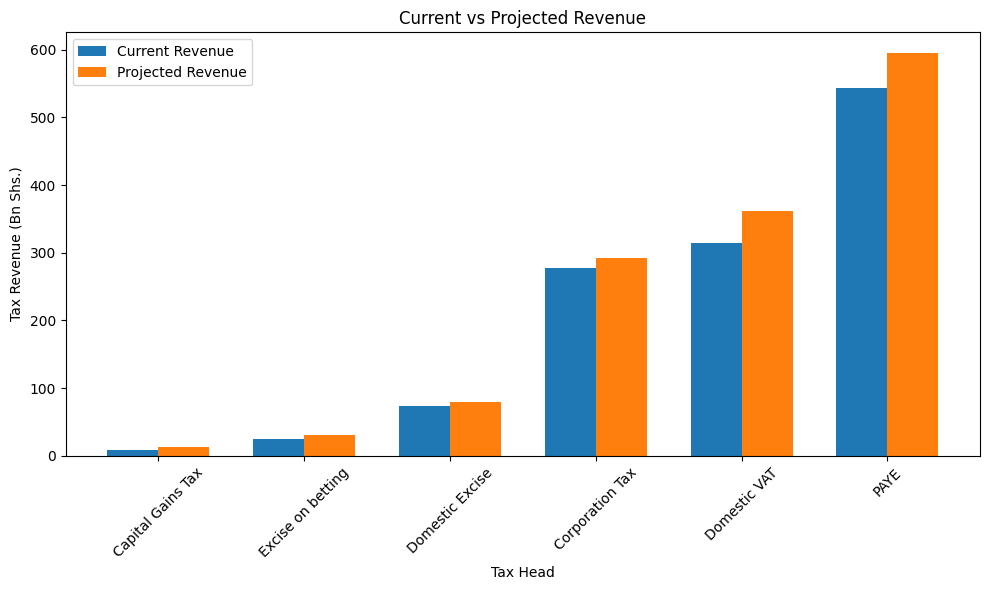

In [29]:
# Current vs Projected Revenue per Tax Head

# Projected Revenue
taxheads['Projected_Revenue'] = taxheads['Tax Revenue (Bn Shs.)'] * (1 + taxheads['Revenue Growth (%)'] / 100)

# Grouped bar chart
width = 0.35
x = np.arange(len(taxheads['Tax Head']))  # number of categories

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, taxheads['Tax Revenue (Bn Shs.)'], width, label='Current Revenue')  # current revenue
plt.bar(x + width/2, taxheads['Projected_Revenue'], width, label='Projected Revenue')  # projected revenue

plt.title('Current vs Projected Revenue')
plt.xlabel('Tax Head')
plt.ylabel('Tax Revenue (Bn Shs.)')
plt.xticks(x, taxheads['Tax Head'], rotation=45)  # category labels, rotate so they don't overlap
plt.legend()
plt.tight_layout()
plt.show()


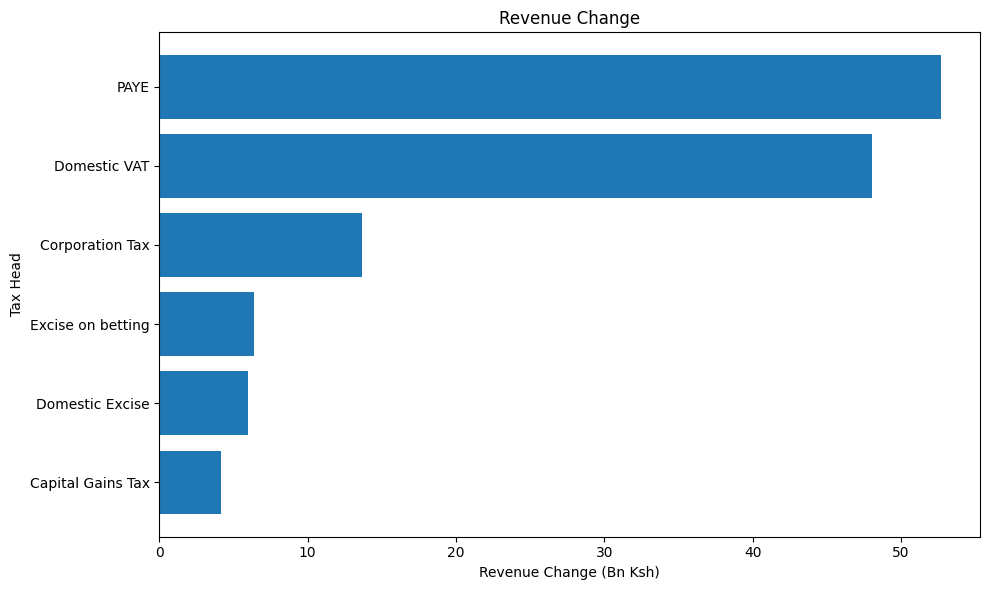

In [33]:
# Which tax head adds the most absolute value next period?

# revenue change
taxheads['Revenue Change'] = taxheads['Projected_Revenue'] - taxheads['Tax Revenue (Bn Shs.)']
taxheads_change_sorted = taxheads.sort_values('Revenue Change')

# horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(taxheads_change_sorted['Tax Head'], taxheads_change_sorted['Revenue Change'])
plt.title('Revenue Change')
plt.xlabel('Revenue Change (Bn Ksh)')
plt.ylabel('Tax Head')
plt.tight_layout()
plt.show()
